<a href="https://colab.research.google.com/github/LeMsnn/Computer-vision/blob/main/Tugas5_Transfer_Learning_235314071.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Minggu 5: Transfer Learning pada Dataset Kecil

**Mata kuliah Computer Vision** | Arsitektur CNN populer (VGG16, ResNet), feature extraction, dan fine-tuning

**Tujuan.** Setelah praktikum ini Anda mampu:

1. menyiapkan dataset citra kecil dengan pembagian latih/validasi/uji yang bebas kebocoran data;
2. membandingkan tiga pendekatan pada data yang sama: (A) CNN kecil dari nol, (B) feature extraction, (C) fine-tuning bertahap;
3. membaca kurva latih-validasi, confusion matrix, dan metrik per kelas untuk menganalisis hasil secara jujur.

**Cara memakai.** Jalankan sel dari atas ke bawah. Notebook ini memakai PyTorch dan torchvision. Lama latih: sekitar 10 sampai 30 menit di CPU untuk 3 sampai 5 kelas dan 100 sampai 300 citra per kelas; jauh lebih cepat di GPU (mis. Google Colab).

**Dataset.** Data tidak diunduh otomatis. Siapkan sendiri dalam folder `data/` dengan satu subfolder per kelas:

```
data/
  kelas_1/  foto001.jpg  foto002.jpg ...
  kelas_2/  ...
  kelas_3/  ...
```

Syarat: 3 sampai 5 kelas, 100 sampai 300 citra per kelas, dikumpulkan atau difoto sendiri (atau dari sumber berlisensi terbuka, mis. Roboflow Universe atau Kaggle; catat sumber dan lisensinya). Hindari foto yang hampir identik dari satu objek yang sama, karena dapat menimbulkan kebocoran data. Bila data memuat wajah atau data pribadi, anonimkan dan pastikan Anda memiliki persetujuan.

## 1. Persiapan lingkungan dan konfigurasi

In [ ]:
# 1. Mount Google Drive dan Pustaka
from google.colab import drive
import os, copy, time, random, json, hashlib
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# ---------------- Konfigurasi Utama untuk Google Colab ----------------
# Path data di Google Drive sesuai lokasi Anda:
DATA_PATH_DRIVE = Path("/content/drive/MyDrive/data (1)")
FALLBACK_PATH   = Path("/content/drive/MyDrive/data")

if DATA_PATH_DRIVE.exists():
    DATA_DIR = DATA_PATH_DRIVE
elif FALLBACK_PATH.exists():
    DATA_DIR = FALLBACK_PATH
elif Path("data").exists():
    DATA_DIR = Path("data")
else:
    DATA_DIR = DATA_PATH_DRIVE

# Folder keluaran di Google Drive agar hasil tidak hilang saat runtime selesai
OUT_DIR = Path("/content/drive/MyDrive/hasil_minggu5")
if not Path("/content/drive/MyDrive").exists():
    OUT_DIR = Path("/content/hasil_minggu5")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME  = "resnet18"        # Arsitektur ResNet18
PRETRAINED  = True              # Menggunakan bobot ImageNet
IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_WORKERS = 2                 # Optimal untuk Google Colab
EPOCHS_A, EPOCHS_B, EPOCHS_C = 15, 10, 8   # Epoch latihan
PATIENCE    = 4                 # Early stopping (berdasarkan val loss)
TEST_FRAC, VAL_FRAC = 0.15, 0.15
SEED        = 42

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 50)
print(f"Perangkat yang digunakan : {device.upper()}")
if device == "cuda":
    print(f"Nama GPU               : {torch.cuda.get_device_name(0)}")
print(f"Versi PyTorch          : {torch.__version__}")
print(f"Folder Dataset         : {DATA_DIR}")
print(f"Folder Hasil           : {OUT_DIR}")
print("=" * 50)

Mounted at /content/drive
Perangkat yang digunakan : CUDA
Nama GPU               : Tesla T4
Versi PyTorch          : 2.11.0+cu130
Folder Dataset         : /content/drive/MyDrive/data (1)
Folder Hasil           : /content/drive/MyDrive/hasil_minggu5


## 2. Memeriksa dataset

Sel berikut memindai folder, memastikan semua berkas dapat dibuka, menghitung jumlah citra per kelas, dan **mendeteksi duplikat persis** (berkas identik) yang akan menimbulkan kebocoran data bila satu salinan masuk data latih dan salinan lain masuk data uji.

,kelas,jumlah_citra
0,Cloudy,291
1,Rain,206
2,Shine,250
3,Sunrise,352


Total citra valid: 1099 | berkas rusak: 0 | duplikat dibuang: 26
Contoh duplikat dibuang: [('/content/drive/MyDrive/data (1)/Cloudy/cloudy146.jpg', '/content/drive/MyDrive/data (1)/Cloudy/cloudy102.jpg'), ('/content/drive/MyDrive/data (1)/Cloudy/cloudy24.jpg', '/content/drive/MyDrive/data (1)/Cloudy/cloudy110.jpg'), ('/content/drive/MyDrive/data (1)/Cloudy/cloudy3.jpg', '/content/drive/MyDrive/data (1)/Cloudy/cloudy115.jpg')]


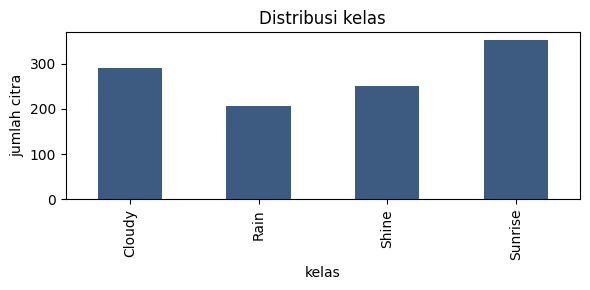

In [ ]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
assert DATA_DIR.exists(), f"Folder {DATA_DIR} tidak ditemukan. Pastikan Google Drive sudah di-mount dan folder ada."

# Deteksi jika data berada dalam subfolder ekstra (misal hasil ekstrak zip)
candidates = [d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".") and d.name.lower() not in ("hasil", "hasil_evaluasi", "__pycache__")]
if len(candidates) == 1 and any(sub.is_dir() for sub in candidates[0].iterdir()):
    print(f"Mendeteksi subfolder ekstra, menggunakan: {candidates[0]}")
    DATA_DIR = candidates[0]

class_names = sorted(d.name for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".") and d.name.lower() not in ("hasil", "hasil_evaluasi", "__pycache__"))
assert len(class_names) >= 2, f"Dibutuhkan minimal 2 subfolder kelas. Ditemukan: {class_names}"

paths, labels, bad_files, seen_hash, duplicates = [], [], [], {}, []
for ci, cname in enumerate(class_names):
    for p in sorted((DATA_DIR / cname).rglob("*")):
        if p.suffix.lower() not in IMG_EXT:
            continue
        try:
            with Image.open(p) as im:
                im.verify()                       # berkas rusak akan memicu error
        except Exception:
            bad_files.append(str(p)); continue
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in seen_hash:                        # duplikat persis -> buang
            duplicates.append((str(p), seen_hash[h])); continue
        seen_hash[h] = str(p)
        paths.append(str(p)); labels.append(ci)

paths, labels = np.array(paths), np.array(labels)
K = len(class_names)
counts = pd.Series(labels).value_counts().sort_index()
df_counts = pd.DataFrame({"kelas": class_names, "jumlah_citra": counts.values})
display(df_counts)
print(f"Total citra valid: {len(paths)} | berkas rusak: {len(bad_files)} | duplikat dibuang: {len(duplicates)}")
if bad_files:   print("Berkas rusak (diabaikan):", bad_files[:5])
if duplicates:  print("Contoh duplikat dibuang:", duplicates[:3])
if counts.min() < 30:
    print("PERINGATAN: ada kelas dengan < 30 citra; hasil akan sangat berisik. Tambah data bila bisa.")
if counts.max() / counts.min() > 3:
    print("PERINGATAN: kelas tidak seimbang (rasio > 3). Pertimbangkan class weight dan laporkan F1 per kelas.")

df_counts.plot.bar(x="kelas", y="jumlah_citra", legend=False, color="#3D5A80", figsize=(6, 3))
plt.ylabel("jumlah citra"); plt.title("Distribusi kelas"); plt.tight_layout(); plt.show()

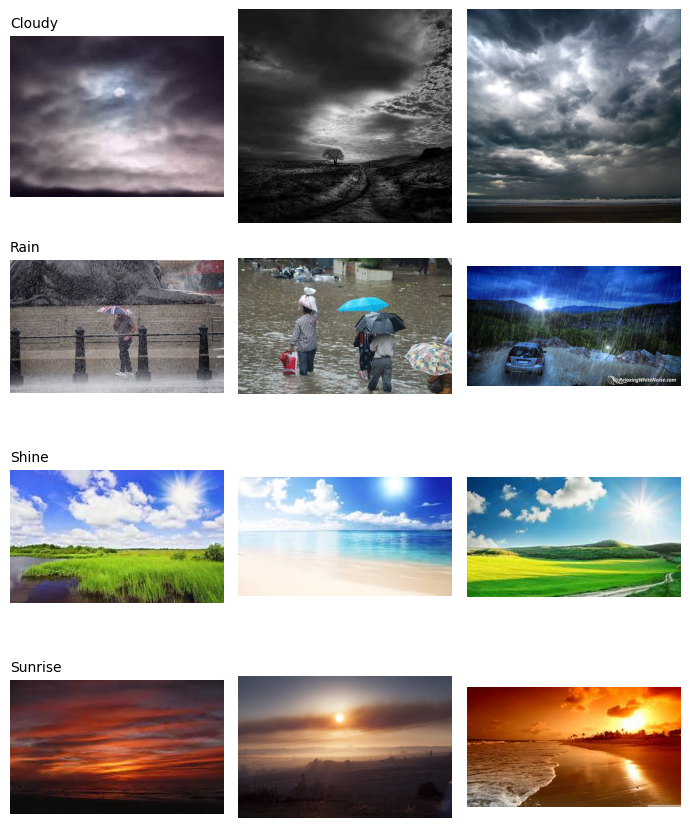

In [ ]:
# Contoh citra: 3 per kelas
fig, axes = plt.subplots(K, 3, figsize=(7, 2.2 * K))
axes = np.atleast_2d(axes)
for ci in range(K):
    sample = np.random.RandomState(SEED).choice(np.where(labels == ci)[0], size=min(3, counts[ci]), replace=False)
    for j in range(3):
        ax = axes[ci, j]; ax.axis("off")
        if j < len(sample):
            ax.imshow(Image.open(paths[sample[j]]).convert("RGB"))
            if j == 0: ax.set_title(class_names[ci], fontsize=10, loc="left")
plt.tight_layout(); plt.show()

## 3. Pembagian data latih / validasi / uji

Pembagian dilakukan **sebelum** augmentasi dan secara **stratified** (proporsi kelas terjaga). Data uji disimpan dan hanya dipakai sekali di akhir untuk melaporkan hasil; data validasi dipakai untuk memantau latihan dan memilih model.

> Catatan: pembagian ini dilakukan per citra. Bila satu objek atau satu subjek (mis. satu pasien, satu pohon) difoto berkali-kali, semua fotonya harus berada di split yang sama (group split). Jelaskan di laporan bagaimana Anda menjaga hal ini.

In [ ]:
idx = np.arange(len(paths))
trval_idx, test_idx = train_test_split(idx, test_size=TEST_FRAC, stratify=labels, random_state=SEED)
train_idx, val_idx = train_test_split(trval_idx, test_size=VAL_FRAC / (1 - TEST_FRAC),
                                      stratify=labels[trval_idx], random_state=SEED)

split_table = pd.DataFrame({
    "kelas": class_names,
    "latih": [int((labels[train_idx] == c).sum()) for c in range(K)],
    "validasi": [int((labels[val_idx] == c).sum()) for c in range(K)],
    "uji": [int((labels[test_idx] == c).sum()) for c in range(K)],
})
display(split_table)
assert len(set(train_idx) & set(val_idx)) == 0 and len(set(train_idx) & set(test_idx)) == 0 and len(set(val_idx) & set(test_idx)) == 0
print("Tidak ada irisan antar split: OK")

,kelas,latih,validasi,uji
0,Cloudy,203,44,44
1,Rain,144,31,31
2,Shine,176,37,37
3,Sunrise,246,53,53


Tidak ada irisan antar split: OK


## 4. Preprocessing dan augmentasi

Model pre-trained mengharapkan masukan dengan normalisasi (mean, std) ImageNet. **Preprocessing evaluasi harus tetap deterministik**; augmentasi hanya untuk data latih.

**TODO 1 (versi mahasiswa):** lengkapi augmentasi data latih. Minimal gunakan `RandomResizedCrop` dan `RandomHorizontalFlip`; pertimbangkan `ColorJitter` ringan. Pilih augmentasi yang masuk akal untuk data Anda (mis. flip horizontal mungkin tidak cocok untuk teks atau citra medis tertentu).

In [ ]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class ImageListDataset(Dataset):
    """Dataset sederhana dari daftar path dan label."""
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), int(self.labels[i])

def make_loader(ids, tf, shuffle):
    ds = ImageListDataset(paths[ids], labels[ids], tf)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS,
                      pin_memory=(device == "cuda"))

train_loader = make_loader(train_idx, train_tf, True)
val_loader   = make_loader(val_idx,   eval_tf,  False)
test_loader  = make_loader(test_idx,  eval_tf,  False)
print("Batch latih:", len(train_loader), "| validasi:", len(val_loader), "| uji:", len(test_loader))

Batch latih: 49 | validasi: 11 | uji: 11


## 5. Fungsi bantu: pelatihan, evaluasi, dan pembekuan layer

Perhatikan dua hal penting untuk transfer learning:

- `bn_eval=True` menjaga layer BatchNorm dalam mode evaluasi selama latihan. Dengan batch kecil, statistik batch tidak stabil dan dapat merusak statistik BatchNorm hasil pre-training.
- Model terbaik dipilih berdasarkan **val loss terendah** (lebih stabil daripada akurasi pada validasi kecil), dengan early stopping.

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def set_bn_eval(model):
    for m in model.modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm):
            m.eval()

def run_epoch(model, loader, criterion, optimizer=None, bn_eval=False):
    """Satu epoch. optimizer=None berarti mode evaluasi."""
    training = optimizer is not None
    model.train(training)
    if training and bn_eval:
        set_bn_eval(model)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n

def fit(model, optimizer, epochs, label, bn_eval=False, patience=PATIENCE):
    """Latih model dengan early stopping; kembalikan (model terbaik, riwayat, detik)."""
    assert optimizer is not None, "optimizer belum dibuat"
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    hist = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_loss, best_state, bad = float("inf"), None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tl, ta = run_epoch(model, train_loader, criterion, optimizer, bn_eval)
        vl, va = run_epoch(model, val_loader, criterion)
        for k, v in zip(hist, (tl, ta, vl, va)):
            hist[k].append(v)
        print(f"[{label}] epoch {ep:02d}/{epochs} | latih loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")
        if vl < best_loss - 1e-4:
            best_loss, best_state, bad = vl, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                print(f"[{label}] early stopping pada epoch {ep}")
                break
    model.load_state_dict(best_state)
    return model, hist, time.time() - t0

@torch.no_grad()
def predict(model, loader):
    """Kembalikan (y_true, y_pred, probabilitas) sesuai urutan loader."""
    model.eval().to(device)
    ys, ps, prs = [], [], []
    for x, y in loader:
        pr = torch.softmax(model(x.to(device)), dim=1).cpu()
        ys.append(y.numpy()); ps.append(pr.argmax(1).numpy()); prs.append(pr.numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(prs)

### Membangun model pre-trained, membekukan, dan membuka layer

`build_model` mengganti layer klasifikasi ImageNet (1000 kelas) menjadi `K` kelas. `get_parts` mengembalikan *head* (layer klasifikasi baru) dan daftar *stage* backbone dari yang paling atas ke bawah, yang akan dibuka bertahap saat fine-tuning.

**TODO 2 (versi mahasiswa):** lengkapi `freeze_backbone`: bekukan seluruh parameter model (`requires_grad = False`) lalu aktifkan kembali hanya parameter head.

In [ ]:
def build_model(name, num_classes, pretrained=True):
    """Muat arsitektur (opsional bobot ImageNet) dan ganti layer klasifikasi terakhir."""
    if name in ("resnet18", "resnet34", "resnet50"):
        weights = getattr(models, f"ResNet{name[6:]}_Weights").DEFAULT if pretrained else None
        model = getattr(models, name)(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "vgg16":
        weights = models.VGG16_Weights.DEFAULT if pretrained else None
        model = models.vgg16(weights=weights)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    else:
        raise ValueError("MODEL_NAME tidak dikenal")
    return model

def get_parts(model, name):
    """Kembalikan (head, stages) ; stages diurutkan dari paling atas (dekat head) ke bawah."""
    if name.startswith("resnet"):
        return model.fc, [model.layer4, model.layer3, model.layer2]
    return model.classifier[6], [model.features[24:], model.features[17:24], model.features[10:17]]

def freeze_backbone(model, head):
    """Bekukan semua parameter, lalu aktifkan hanya parameter head."""
    for p in model.parameters():
        p.requires_grad = False
    for p in head.parameters():
        p.requires_grad = True

def unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True

## 6. Eksperimen A: CNN kecil dari nol (baseline)

Baseline wajib ada. Tanpa baseline, kita tidak dapat menyatakan bahwa transfer learning bermanfaat.

In [ ]:
class SmallCNN(nn.Module):
    """CNN kecil: 4 blok (Conv-BN-ReLU-MaxPool) + global average pooling + dropout + FC."""
    def __init__(self, num_classes):
        super().__init__()
        def block(i, o):
            return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 128))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)).flatten(1))

set_seed()
model_a = SmallCNN(K)
print("Parameter (total, dilatih):", count_params(model_a))
opt_a = torch.optim.Adam(model_a.parameters(), lr=1e-3)
model_a, hist_a, t_a = fit(model_a, opt_a, EPOCHS_A, label="A scratch")

Parameter (total, dilatih): (242052, 242052)
[A scratch] epoch 01/15 | latih loss 0.614 acc 0.772 | val loss 0.494 acc 0.812
[A scratch] epoch 02/15 | latih loss 0.472 acc 0.826 | val loss 0.292 acc 0.873
[A scratch] epoch 03/15 | latih loss 0.476 acc 0.836 | val loss 0.273 acc 0.885
[A scratch] epoch 04/15 | latih loss 0.387 acc 0.871 | val loss 0.490 acc 0.818
[A scratch] epoch 05/15 | latih loss 0.402 acc 0.857 | val loss 0.274 acc 0.933
[A scratch] epoch 06/15 | latih loss 0.403 acc 0.871 | val loss 0.285 acc 0.867
[A scratch] epoch 07/15 | latih loss 0.416 acc 0.854 | val loss 0.226 acc 0.897
[A scratch] epoch 08/15 | latih loss 0.397 acc 0.844 | val loss 0.227 acc 0.927
[A scratch] epoch 09/15 | latih loss 0.331 acc 0.891 | val loss 0.250 acc 0.903
[A scratch] epoch 10/15 | latih loss 0.342 acc 0.882 | val loss 0.302 acc 0.842
[A scratch] epoch 11/15 | latih loss 0.353 acc 0.862 | val loss 0.273 acc 0.891
[A scratch] early stopping pada epoch 11


## 7. Eksperimen B: feature extraction (linear probe)

Backbone pre-trained **dibekukan**; hanya layer klasifikasi baru yang dilatih dengan learning rate 1e-3. Cepat, hemat memori, dan sering sudah menjadi baseline yang kuat.

In [ ]:
set_seed()
model_b = build_model(MODEL_NAME, K, PRETRAINED)
head_b, stages_b = get_parts(model_b, MODEL_NAME)
freeze_backbone(model_b, head_b)
total, trainable = count_params(model_b)
print(f"Parameter total {total:,} | dilatih {trainable:,} ({100 * trainable / total:.3f}%)")

opt_b = torch.optim.Adam([p for p in model_b.parameters() if p.requires_grad], lr=1e-3)
model_b, hist_b, t_b = fit(model_b, opt_b, EPOCHS_B, label="B feature extraction", bn_eval=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


Parameter total 11,178,564 | dilatih 2,052 (0.018%)
[B feature extraction] epoch 01/10 | latih loss 0.885 acc 0.713 | val loss 0.429 acc 0.952
[B feature extraction] epoch 02/10 | latih loss 0.335 acc 0.948 | val loss 0.283 acc 0.939
[B feature extraction] epoch 03/10 | latih loss 0.224 acc 0.958 | val loss 0.208 acc 0.939
[B feature extraction] epoch 04/10 | latih loss 0.188 acc 0.960 | val loss 0.184 acc 0.939
[B feature extraction] epoch 05/10 | latih loss 0.155 acc 0.969 | val loss 0.164 acc 0.945
[B feature extraction] epoch 06/10 | latih loss 0.132 acc 0.964 | val loss 0.134 acc 0.958
[B feature extraction] epoch 07/10 | latih loss 0.118 acc 0.970 | val loss 0.131 acc 0.952
[B feature extraction] epoch 08/10 | latih loss 0.106 acc 0.971 | val loss 0.119 acc 0.958
[B feature extraction] epoch 09/10 | latih loss 0.106 acc 0.970 | val loss 0.129 acc 0.952
[B feature extraction] epoch 10/10 | latih loss 0.099 acc 0.978 | val loss 0.116 acc 0.952


## 8. Eksperimen C: fine-tuning bertahap (LP-FT)

Mulai dari model B yang headnya sudah terlatih (*linear probe lalu fine-tune*), kemudian buka layer dari atas ke bawah dengan **learning rate berbeda** untuk setiap bagian:

| Tahap | Bagian yang dilatih | LR |
|---|---|---|
| C1 | head + stage teratas (`layer4` pada ResNet) | head 3e-4, stage 1e-4 |
| C2 | head + dua stage teratas (`layer4`, `layer3`) | head 3e-4, `layer4` 1e-4, `layer3` 3e-5 |

**TODO 3 (versi mahasiswa):** buat optimizer dengan *parameter groups* sehingga tiap bagian memakai LR yang berbeda (lihat tabel). Contoh sintaks:
`torch.optim.Adam([{"params": bagian_1.parameters(), "lr": lr_1}, {"params": bagian_2.parameters(), "lr": lr_2}])`

In [ ]:
# ---- Tahap C1: buka stage teratas ----
set_seed()
model_c1 = copy.deepcopy(model_b)              # mulai dari head yang sudah terlatih (LP-FT)
head_c1, stages_c1 = get_parts(model_c1, MODEL_NAME)
unfreeze(stages_c1[0])
total, trainable = count_params(model_c1)
print(f"C1: parameter dilatih {trainable:,} ({100 * trainable / total:.2f}%)")

opt_c1 = torch.optim.Adam([
    {"params": head_c1.parameters(),      "lr": 3e-4},
    {"params": stages_c1[0].parameters(), "lr": 1e-4},
])
model_c1, hist_c1, t_c1 = fit(model_c1, opt_c1, EPOCHS_C, label="C1 FT stage-1", bn_eval=True)

# ---- Tahap C2: buka satu stage lagi ----
model_c2 = copy.deepcopy(model_c1)
head_c2, stages_c2 = get_parts(model_c2, MODEL_NAME)
unfreeze(stages_c2[1])
total, trainable = count_params(model_c2)
print(f"C2: parameter dilatih {trainable:,} ({100 * trainable / total:.2f}%)")

opt_c2 = torch.optim.Adam([
    {"params": head_c2.parameters(),      "lr": 3e-4},
    {"params": stages_c2[0].parameters(), "lr": 1e-4},
    {"params": stages_c2[1].parameters(), "lr": 3e-5},
])
model_c2, hist_c2, t_c2 = fit(model_c2, opt_c2, EPOCHS_C, label="C2 FT stage-1+2", bn_eval=True)

C1: parameter dilatih 8,395,780 (75.11%)
[C1 FT stage-1] epoch 01/8 | latih loss 0.193 acc 0.928 | val loss 0.110 acc 0.945
[C1 FT stage-1] epoch 02/8 | latih loss 0.064 acc 0.978 | val loss 0.072 acc 0.976
[C1 FT stage-1] epoch 03/8 | latih loss 0.057 acc 0.980 | val loss 0.065 acc 0.976
[C1 FT stage-1] epoch 04/8 | latih loss 0.024 acc 0.990 | val loss 0.071 acc 0.958
[C1 FT stage-1] epoch 05/8 | latih loss 0.024 acc 0.993 | val loss 0.098 acc 0.964
[C1 FT stage-1] epoch 06/8 | latih loss 0.034 acc 0.987 | val loss 0.203 acc 0.933
[C1 FT stage-1] epoch 07/8 | latih loss 0.007 acc 0.999 | val loss 0.088 acc 0.964
[C1 FT stage-1] early stopping pada epoch 7
C2: parameter dilatih 10,495,492 (93.89%)
[C2 FT stage-1+2] epoch 01/8 | latih loss 0.071 acc 0.975 | val loss 0.090 acc 0.958
[C2 FT stage-1+2] epoch 02/8 | latih loss 0.032 acc 0.987 | val loss 0.075 acc 0.988
[C2 FT stage-1+2] epoch 03/8 | latih loss 0.100 acc 0.969 | val loss 0.061 acc 0.976
[C2 FT stage-1+2] epoch 04/8 | latih 

## 9. Perbandingan hasil

Data uji baru dipakai di sini. Pilih model terbaik berdasarkan **validasi**, bukan berdasarkan data uji, lalu laporkan hasil uji untuk semua model secara jujur.

In [ ]:
experiments = {
    "A. CNN dari nol":        (model_a,  hist_a,  t_a),
    "B. Feature extraction":  (model_b,  hist_b,  t_b),
    "C1. Fine-tune stage 1":  (model_c1, hist_c1, t_c1),
    "C2. Fine-tune stage 1+2": (model_c2, hist_c2, t_c2),
}

rows = []
for name, (m, h, secs) in experiments.items():
    best = int(np.argmin(h["val_loss"]))
    y_t, y_p, _ = predict(m, test_loader)
    total, trainable = count_params(m)
    rows.append({
        "eksperimen": name,
        "param dilatih": trainable,
        "epoch dijalankan": len(h["val_loss"]),
        "val loss": round(h["val_loss"][best], 4),
        "val acc": round(h["val_acc"][best], 4),
        "uji acc": round(accuracy_score(y_t, y_p), 4),
        "uji F1 (macro)": round(f1_score(y_t, y_p, average="macro"), 4),
        "waktu latih (s)": round(secs, 1),
    })
results = pd.DataFrame(rows)
display(results)
results.to_csv(OUT_DIR / "ringkasan_hasil.csv", index=False)

best_name = results.sort_values(["val acc", "val loss"], ascending=[False, True]).iloc[0]["eksperimen"]
print("Model terbaik menurut VALIDASI:", best_name)

,eksperimen,param dilatih,epoch dijalankan,val loss,val acc,uji acc,uji F1 (macro),waktu latih (s)
0,A. CNN dari nol,242052,11,0.2262,0.8970,0.9455,0.9434,121.5
1,B. Feature extraction,2052,10,0.1161,0.9515,0.9758,0.9740,102.1
2,C1. Fine-tune stage 1,8395780,7,0.0649,0.9758,0.9879,0.9869,79.7
3,C2. Fine-tune stage 1+2,10495492,7,0.0610,0.9758,0.9818,0.9812,75.9


Model terbaik menurut VALIDASI: C2. Fine-tune stage 1+2


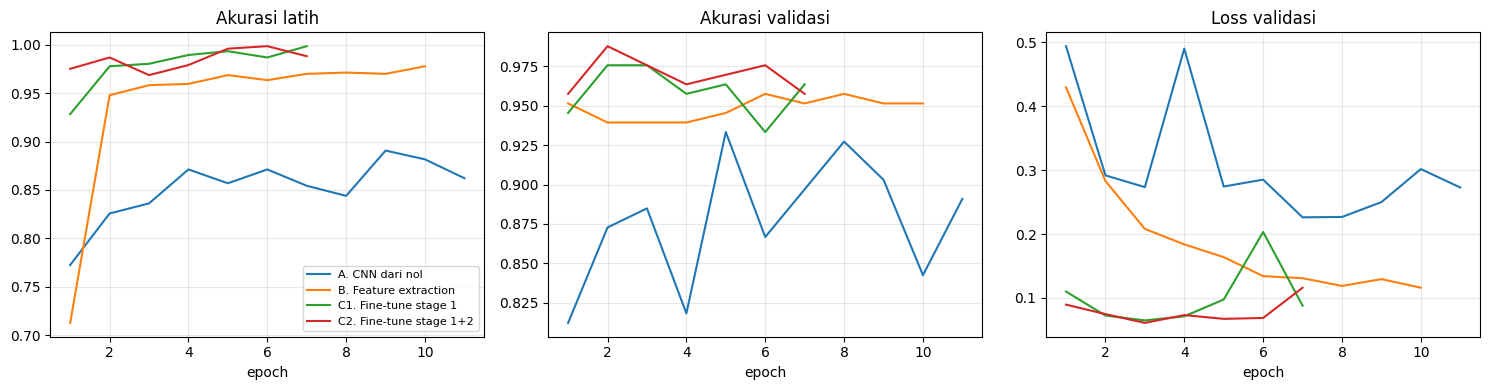

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for name, (m, h, secs) in experiments.items():
    ep = range(1, len(h["val_loss"]) + 1)
    axes[0].plot(ep, h["train_acc"], label=name)
    axes[1].plot(ep, h["val_acc"], label=name)
    axes[2].plot(ep, h["val_loss"], label=name)
for ax, t in zip(axes, ["Akurasi latih", "Akurasi validasi", "Loss validasi"]):
    ax.set_title(t); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "kurva_latih.png", dpi=150)
plt.show()

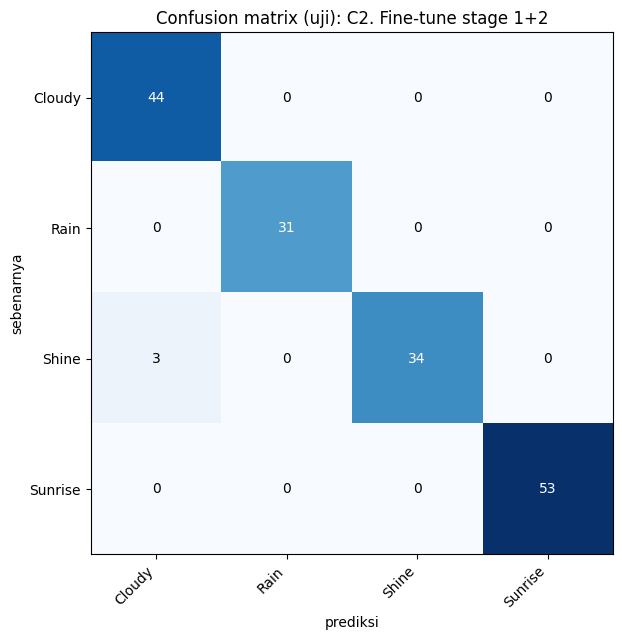

              precision    recall  f1-score   support

      Cloudy      0.936     1.000     0.967        44
        Rain      1.000     1.000     1.000        31
       Shine      1.000     0.919     0.958        37
     Sunrise      1.000     1.000     1.000        53

    accuracy                          0.982       165
   macro avg      0.984     0.980     0.981       165
weighted avg      0.983     0.982     0.982       165



In [ ]:
best_model = experiments[best_name][0]
y_t, y_p, y_prob = predict(best_model, test_loader)

def plot_cm(y_true, y_pred, names, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(names))))
    fig, ax = plt.subplots(figsize=(1.0 * len(names) + 3, 1.0 * len(names) + 2.5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
    ax.set_xlabel("prediksi"); ax.set_ylabel("sebenarnya"); ax.set_title(title)
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=150); plt.show()

plot_cm(y_t, y_p, class_names, f"Confusion matrix (uji): {best_name}")
print(classification_report(y_t, y_p, target_names=class_names, digits=3, zero_division=0))

## 10. Analisis kesalahan dan inferensi

Angka akurasi saja tidak cukup. Lihat citra yang salah diprediksi: apakah kesalahannya masuk akal (objek memang mirip), atau ada masalah pada data (label salah, latar belakang yang bias, pencahayaan)?

Salah prediksi: 3 dari 165 citra uji


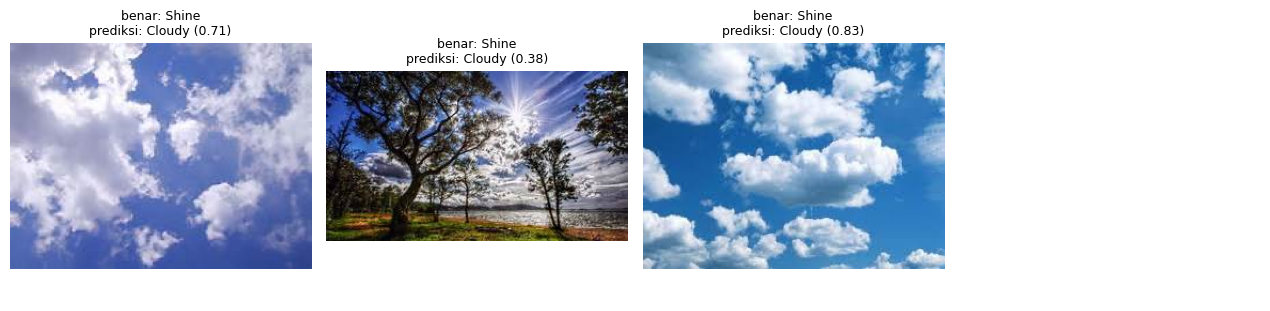

In [ ]:
wrong = np.where(y_t != y_p)[0]
print(f"Salah prediksi: {len(wrong)} dari {len(y_t)} citra uji")
show = wrong[:8]
if len(show):
    cols = 4; rows_n = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows_n, cols, figsize=(3.2 * cols, 3.2 * rows_n))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for ax, k in zip(np.atleast_1d(axes).ravel(), show):
        ax.imshow(Image.open(paths[test_idx[k]]).convert("RGB"))
        ax.set_title(f"benar: {class_names[y_t[k]]}\nprediksi: {class_names[y_p[k]]} ({y_prob[k, y_p[k]]:.2f})", fontsize=9)
    plt.tight_layout(); plt.savefig(OUT_DIR / "salah_prediksi.png", dpi=150); plt.show()

def predict_image(path, model=best_model, topk=3):
    """Prediksi satu citra baru; tampilkan top-k kelas."""
    img = Image.open(path).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    model.eval().to(device)
    with torch.no_grad():
        pr = torch.softmax(model(x), dim=1)[0].cpu().numpy()
    top = pr.argsort()[::-1][:topk]
    print(f"Berkas: {path}")
    for t in top:
        print(f"  {class_names[t]:<20s} {pr[t]:.3f}")

# Contoh: predict_image(paths[test_idx[0]])

In [ ]:
# Simpan model terbaik dan daftar kelas untuk dipakai ulang
torch.save({"state_dict": best_model.state_dict(), "class_names": class_names,
            "model_name": MODEL_NAME if best_name != "A. CNN dari nol" else "SmallCNN"},
           OUT_DIR / "model_terbaik.pt")
with open(OUT_DIR / "kelas.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)
print("Tersimpan di folder:", OUT_DIR.resolve())

Tersimpan di folder: /content/drive/MyDrive/hasil_minggu5



## 11. Refleksi dan panduan interpretasi (versi dosen)

Gunakan pertanyaan berikut untuk menyusun paragraf analisis pada laporan.

1. **Dibandingkan baseline.** Apakah B dan C lebih baik daripada A? Seberapa besar selisih akurasi validasi dan uji, dan apakah selisih itu cukup besar dibandingkan ketidakpastian pada data sekecil ini (jumlah citra uji per kelas)?
2. **Overfitting.** Bandingkan akurasi latih dan validasi tiap eksperimen. Eksperimen mana yang paling overfit, dan mengapa?
3. **Fine-tuning vs feature extraction.** Apakah membuka layer (C1, C2) memperbaiki hasil B? Bila tidak, apa penjelasan yang mungkin (data terlalu sedikit, domain mirip ImageNet, learning rate)?
4. **Trade-off.** Bandingkan jumlah parameter yang dilatih dan waktu latih terhadap peningkatan akurasi.
5. **Analisis kesalahan.** Kelas mana yang paling sering tertukar, dan apakah penyebabnya terlihat pada citra (kemiripan visual, latar belakang, kualitas foto)?
6. **Keterbatasan dan etika.** Apa batas kesimpulan Anda (jumlah data, satu domain, satu split)? Bila data memuat wajah atau data pribadi, bagaimana privasi dan persetujuan dijaga?

**Panduan interpretasi untuk dosen.**

- B biasanya jauh di atas A pada data kecil; C1 sering memberi tambahan kecil; C2 dapat sama atau lebih buruk (data sedikit, risiko overfit). Hasil yang tidak mengikuti pola ini tetap valid bila dianalisis dengan jujur.
- Selisih satu atau dua citra uji dapat mengubah akurasi beberapa persen; dorong mahasiswa mengulang dengan beberapa nilai `SEED` dan melaporkan rata-rata dan simpangan baku.
- Bila C jauh lebih buruk daripada B dengan akurasi latih ikut rendah, curigai learning rate terlalu besar (catastrophic forgetting) atau BatchNorm yang tidak dijaga.

**Tantangan opsional.** Ganti `MODEL_NAME` menjadi `"vgg16"` dan bandingkan jumlah parameter, memori, dan waktu latih dengan ResNet-18. Coba juga `resnet50`, atau ubah rasio data latih untuk melihat bagaimana manfaat transfer learning berubah ketika data bertambah.
